# AlphaGenome Gene Expression Predictions — Evaluation

This notebook evaluates the predicted human/chimp gene expression LFC values produced by `ag_predictions.py`.

**Sections**
1. Setup & Data Loading
2. Data Quality Overview
3. LFC Distribution
4. Top Differentially Expressed Genes
5. Species Expression Levels
6. Comparison with Hybrid ASE Data (LFC correlation & direction accuracy)
7. Predicted vs Experimental Per-Species Expression
8. Lineage-Causing Change Analysis
9. Summary

## 1. Setup & Data Loading

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr, spearmanr, gaussian_kde
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import config

RESULTS_DIR = Path('./results/all_genes')
FIGSIZE_WIDE = (14, 5)
FIGSIZE_SQ   = (7, 6)

In [2]:
tsv_files = sorted(RESULTS_DIR.glob('lfc_df_*.tsv'))
print(f'Found {len(tsv_files)} result chunk(s)')

if len(tsv_files) == 0:
    raise FileNotFoundError(f'No result TSVs found in {RESULTS_DIR}. Wait for cluster jobs to finish.')

df = pl.concat([pl.read_csv(f, separator='\t') for f in tsv_files])
print(f'Total rows loaded : {df.height:,}')
print(f'Columns           : {df.columns}')
df.head()

Found 34 result chunk(s)
Total rows loaded : 17,000
Columns           : ['GeneSymbol', 'HumanGeneID', 'ChimpGeneID', 'LFC', 'HumanGeneExpression', 'ChimpGeneExpression']


GeneSymbol,HumanGeneID,ChimpGeneID,LFC,HumanGeneExpression,ChimpGeneExpression
str,i64,i64,f64,f64,f64
"""SAMD11""",148398,100608581,5.605576,0.302199,0.006206
"""NOC2L""",26155,100608665,5.298696,1.664787,0.042295
"""KLHL17""",339451,465388,13.25118,0.33285,0.000034
"""PLEKHN1""",84069,100608864,10.237682,0.031878,0.000026
"""PERM1""",84808,100609047,-4.686088,0.001225,0.031547


## 2. Data Quality Overview

In [3]:
total        = df.height
null_lfc     = df['LFC'].null_count()
null_human   = df['HumanGeneExpression'].null_count()
null_chimp   = df['ChimpGeneExpression'].null_count()
complete     = df.drop_nulls(subset=['LFC', 'HumanGeneExpression', 'ChimpGeneExpression']).height

print(f'Total gene pairs processed : {total:,}')
print(f'Complete pairs (both expr) : {complete:,}  ({100*complete/total:.1f}%)')
print(f'Missing LFC                : {null_lfc:,}')
print(f'Missing human expression   : {null_human:,}')
print(f'Missing chimp expression   : {null_chimp:,}')

Total gene pairs processed : 17,000
Complete pairs (both expr) : 16,970  (99.8%)
Missing LFC                : 30
Missing human expression   : 1
Missing chimp expression   : 30


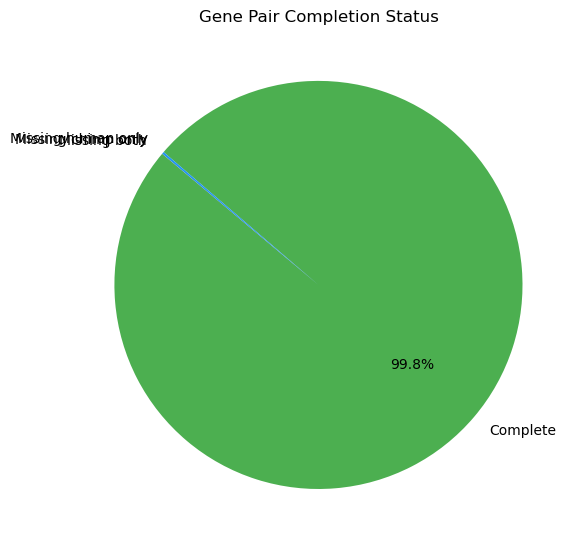

  Complete                 : 16,970
  Missing human only       : 0
  Missing chimp only       : 29
  Missing both             : 1


In [4]:
# Breakdown: both missing vs one species missing
missing_human_only  = df.filter(df['HumanGeneExpression'].is_null() & df['ChimpGeneExpression'].is_not_null()).height
missing_chimp_only  = df.filter(df['ChimpGeneExpression'].is_null() & df['HumanGeneExpression'].is_not_null()).height
missing_both        = df.filter(df['HumanGeneExpression'].is_null() & df['ChimpGeneExpression'].is_null()).height

labels  = ['Complete', 'Missing human only', 'Missing chimp only', 'Missing both']
sizes   = [complete, missing_human_only, missing_chimp_only, missing_both]
colors  = ['#4CAF50', '#FF9800', '#2196F3', '#F44336']

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    sizes, labels=labels, colors=colors,
    autopct=lambda p: f'{p:.1f}%' if p > 1 else '',
    startangle=140
)
ax.set_title('Gene Pair Completion Status')
plt.tight_layout()
plt.show()

for l, s in zip(labels, sizes):
    print(f'  {l:<25}: {s:,}')

In [5]:
# Work with complete pairs from here on
df_clean = df.drop_nulls(subset=['LFC', 'HumanGeneExpression', 'ChimpGeneExpression'])
lfc        = df_clean['LFC'].to_numpy()
human_expr = df_clean['HumanGeneExpression'].to_numpy()
chimp_expr = df_clean['ChimpGeneExpression'].to_numpy()
print(f'Working with {len(lfc):,} complete gene pairs')

Working with 16,970 complete gene pairs


## 3. LFC Distribution

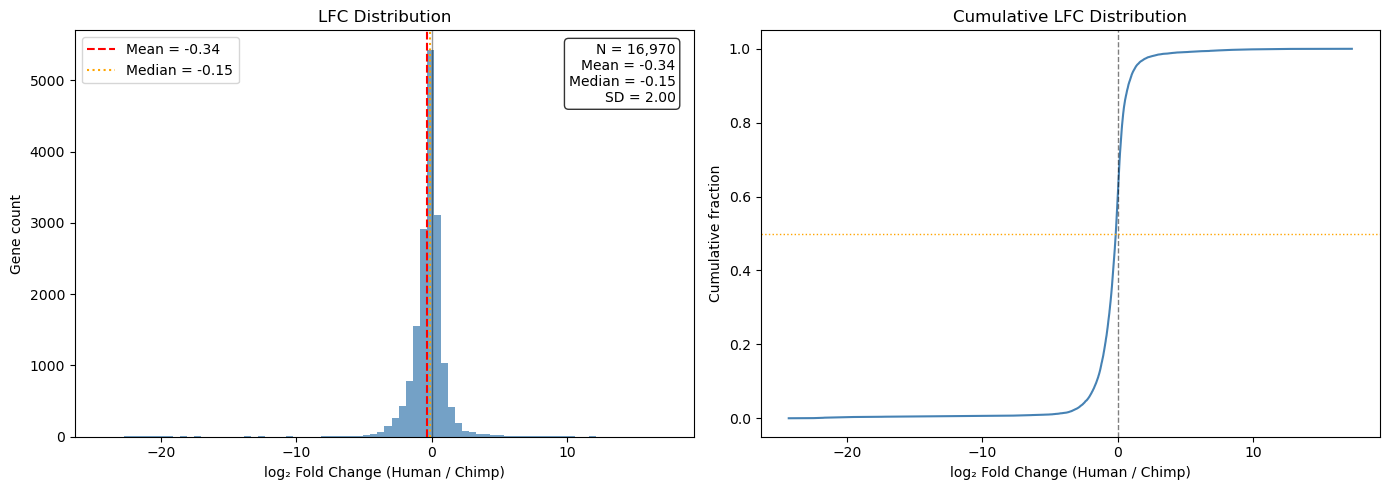

Human-biased genes (LFC > 0): 6,753  (39.8%)
Chimp-biased genes  (LFC < 0): 10,217  (60.2%)


In [6]:
mean_lfc   = np.mean(lfc)
median_lfc = np.median(lfc)
std_lfc    = np.std(lfc)
n_human_biased = np.sum(lfc > 0)
n_chimp_biased = np.sum(lfc < 0)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Histogram
ax = axes[0]
ax.hist(lfc, bins=80, color='steelblue', alpha=0.75, edgecolor='none')
ax.axvline(mean_lfc,   color='red',    linestyle='--', linewidth=1.5, label=f'Mean = {mean_lfc:.2f}')
ax.axvline(median_lfc, color='orange', linestyle=':',  linewidth=1.5, label=f'Median = {median_lfc:.2f}')
ax.axvline(0,          color='black',  linestyle='-',  linewidth=1,   alpha=0.4)
ax.set_xlabel('log\u2082 Fold Change (Human / Chimp)')
ax.set_ylabel('Gene count')
ax.set_title('LFC Distribution')
ax.legend()
stats_text = f'N = {len(lfc):,}\nMean = {mean_lfc:.2f}\nMedian = {median_lfc:.2f}\nSD = {std_lfc:.2f}'
ax.text(0.97, 0.97, stats_text, transform=ax.transAxes, va='top', ha='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Cumulative
ax = axes[1]
sorted_lfc = np.sort(lfc)
cumulative = np.arange(1, len(sorted_lfc)+1) / len(sorted_lfc)
ax.plot(sorted_lfc, cumulative, color='steelblue', linewidth=1.5)
ax.axvline(0,   color='black',  linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(0.5, color='orange', linestyle=':',  linewidth=1)
ax.set_xlabel('log\u2082 Fold Change (Human / Chimp)')
ax.set_ylabel('Cumulative fraction')
ax.set_title('Cumulative LFC Distribution')

plt.tight_layout()
plt.show()

print(f'Human-biased genes (LFC > 0): {n_human_biased:,}  ({100*n_human_biased/len(lfc):.1f}%)')
print(f'Chimp-biased genes  (LFC < 0): {n_chimp_biased:,}  ({100*n_chimp_biased/len(lfc):.1f}%)')

In [7]:
# LFC magnitude breakdown
thresholds = [1, 2, 3, 5]
print('LFC magnitude breakdown (|LFC| threshold):')
print(f'  {"Threshold":<12} {"Human-biased":>14} {"Chimp-biased":>14}')
for t in thresholds:
    nh = np.sum(lfc >  t)
    nc = np.sum(lfc < -t)
    print(f'  |LFC| > {t:<4}  {nh:>10,} ({100*nh/len(lfc):5.1f}%)  {nc:>10,} ({100*nc/len(lfc):5.1f}%)')

LFC magnitude breakdown (|LFC| threshold):
  Threshold      Human-biased   Chimp-biased
  |LFC| > 1          1,247 (  7.3%)       3,141 ( 18.5%)
  |LFC| > 2            459 (  2.7%)       1,086 (  6.4%)
  |LFC| > 3            266 (  1.6%)         451 (  2.7%)
  |LFC| > 5            154 (  0.9%)         175 (  1.0%)


## 4. Top Differentially Expressed Genes

In [8]:
TOP_N = 20

top_human = df_clean.sort('LFC', descending=True).head(TOP_N).select(
    ['GeneSymbol', 'HumanGeneID', 'ChimpGeneID', 'LFC', 'HumanGeneExpression', 'ChimpGeneExpression']
)
top_chimp = df_clean.sort('LFC', descending=False).head(TOP_N).select(
    ['GeneSymbol', 'HumanGeneID', 'ChimpGeneID', 'LFC', 'HumanGeneExpression', 'ChimpGeneExpression']
)

print(f'=== Top {TOP_N} Human-upregulated genes ===')
print(top_human.to_pandas().to_string(index=False))
print()
print(f'=== Top {TOP_N} Chimp-upregulated genes ===')
print(top_chimp.to_pandas().to_string(index=False))

=== Top 20 Human-upregulated genes ===
GeneSymbol  HumanGeneID  ChimpGeneID       LFC  HumanGeneExpression  ChimpGeneExpression
      AGRN       375790    100609326 17.273851             2.858786         1.803991e-05
  C1orf159        54991       457179 15.880233             0.373996         6.200692e-06
   CEACAM5         1048       456062 14.326438             0.133273         6.487180e-06
     IFNA6         3443       473196 14.137569             0.020584         1.142086e-06
    KLHL17       339451       465388 13.251180             0.332850         3.413862e-05
     CCL18         6362       468224 12.744025             0.103595         1.510093e-05
     CXCR5          643       451595 12.637794             0.812786         1.275326e-04
     ELANE         1991    129138043 12.624333             2.387741         3.781675e-04
      MUC6         4588       466311 12.340356             0.123298         2.377604e-05
     AMPD1          270       457144 12.189908             0.371954    

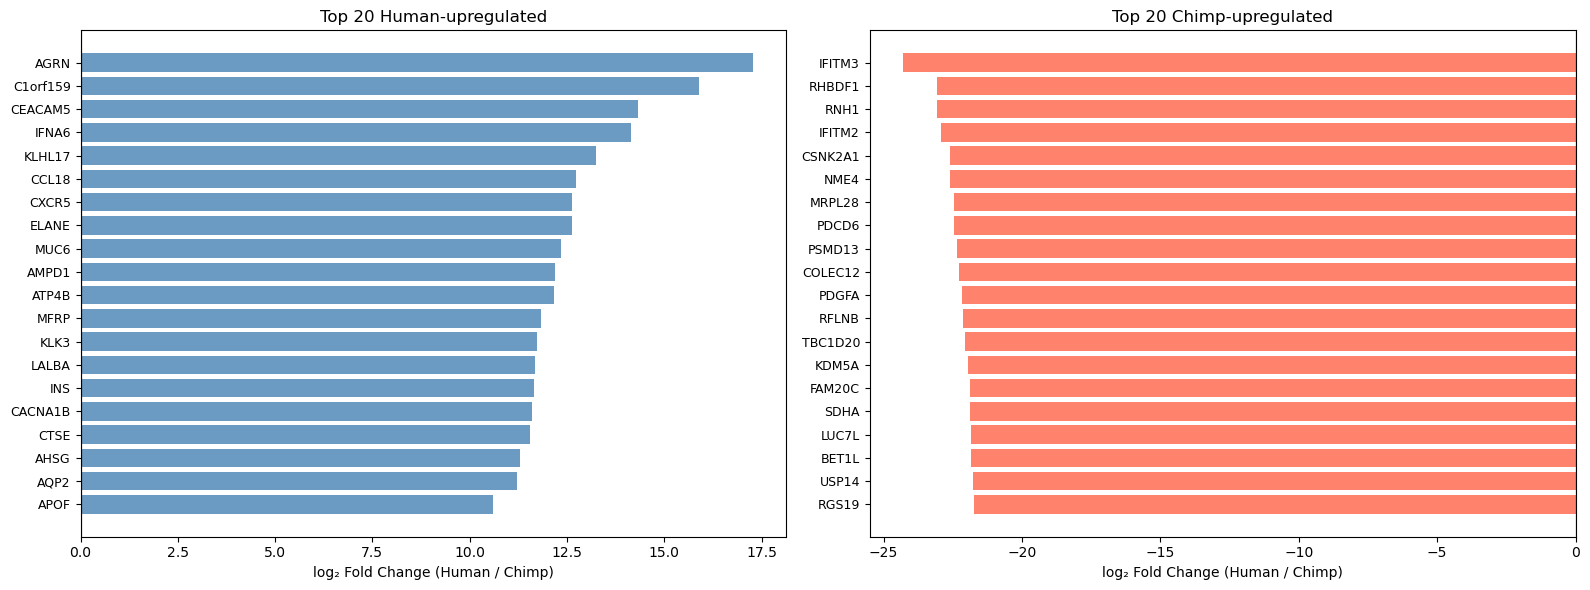

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title, color in [
    (axes[0], top_human, f'Top {TOP_N} Human-upregulated', 'steelblue'),
    (axes[1], top_chimp, f'Top {TOP_N} Chimp-upregulated', 'tomato'),
]:
    genes = data['GeneSymbol'].to_list()
    lfcs  = data['LFC'].to_numpy()
    ax.barh(range(len(genes)), lfcs, color=color, alpha=0.8)
    ax.set_yticks(range(len(genes)))
    ax.set_yticklabels(genes, fontsize=9)
    ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('log\u2082 Fold Change (Human / Chimp)')
    ax.set_title(title)

plt.tight_layout()
plt.show()

## 5. Species Expression Levels

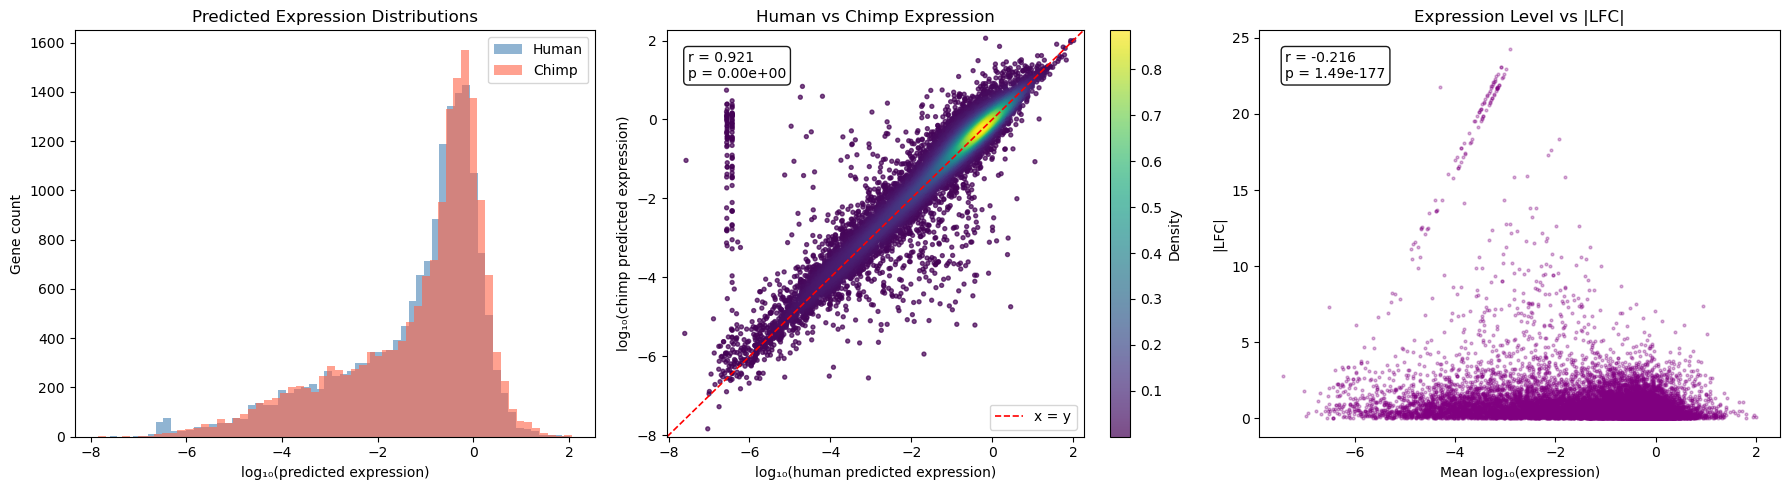

In [10]:
log_human = np.log10(human_expr + 1e-9)
log_chimp = np.log10(chimp_expr + 1e-9)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution per species
ax = axes[0]
ax.hist(log_human, bins=60, alpha=0.6, label='Human', color='steelblue')
ax.hist(log_chimp, bins=60, alpha=0.6, label='Chimp', color='tomato')
ax.set_xlabel('log\u2081\u2080(predicted expression)')
ax.set_ylabel('Gene count')
ax.set_title('Predicted Expression Distributions')
ax.legend()

# Human vs chimp scatter (density-coloured)
ax = axes[1]
mask = np.isfinite(log_human) & np.isfinite(log_chimp)
xp, yp = log_human[mask], log_chimp[mask]
xy = np.vstack([xp, yp])
z  = gaussian_kde(xy)(xy)
idx = z.argsort()
sc = ax.scatter(xp[idx], yp[idx], c=z[idx], cmap='viridis', s=8, alpha=0.7)
lims = [min(xp.min(), yp.min()) - 0.2, max(xp.max(), yp.max()) + 0.2]
ax.plot(lims, lims, 'r--', linewidth=1.2, label='x = y')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('log\u2081\u2080(human predicted expression)')
ax.set_ylabel('log\u2081\u2080(chimp predicted expression)')
ax.set_title('Human vs Chimp Expression')
r, p = pearsonr(xp, yp)
ax.text(0.05, 0.95, f'r = {r:.3f}\np = {p:.2e}', transform=ax.transAxes,
        va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
plt.colorbar(sc, ax=ax, label='Density')
ax.legend()

# Expression vs |LFC|
ax = axes[2]
mean_log_expr = (log_human + log_chimp) / 2
abs_lfc = np.abs(lfc)
mask2 = np.isfinite(mean_log_expr) & np.isfinite(abs_lfc)
ax.scatter(mean_log_expr[mask2], abs_lfc[mask2], s=4, alpha=0.3, color='purple')
ax.set_xlabel('Mean log\u2081\u2080(expression)')
ax.set_ylabel('|LFC|')
ax.set_title('Expression Level vs |LFC|')
r2, p2 = pearsonr(mean_log_expr[mask2], abs_lfc[mask2])
ax.text(0.05, 0.95, f'r = {r2:.3f}\np = {p2:.2e}', transform=ax.transAxes,
        va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.show()

## 6. Comparison with Hybrid ASE Data

In [11]:
hybrids = pl.read_csv(config.HUMAN_CHIMP_HYBRIDS_DATA_PATH_WEXAC, separator='\t')
print(f'Hybrid ASE rows : {hybrids.height:,}')
print(f'Columns         : {hybrids.columns}')
hybrids.head(3)

Hybrid ASE rows : 92,618
Columns         : ['Gene', 'Chromosome', 'Start(hg38)', 'End(hg38)', 'Start(hg19)', 'End(hg19)', 'Strand', 'ID(ENTREZ)', 'Gene type', 'TSS', 'ID(Ensemble)', 'AllFibroblasts_LFC_human_ref', 'AllFibroblasts_LFC_padj_human_ref', 'AllFibroblasts_LFC_chimp_ref', 'AllFibroblasts_LFC_padj_chimp_ref', 'AllFibroblasts_TPM_human_allele', 'AllFibroblasts_TPM_chimp_allele', 'AllFibroblasts_TPM_total', 'AllFollicle_LFC_human_ref', 'AllFollicle_LFC_padj_human_ref', 'AllFollicle_LFC_chimp_ref', 'AllFollicle_LFC_padj_chimp_ref', 'AllFollicle_TPM_human_allele', 'AllFollicle_TPM_chimp_allele', 'AllFollicle_TPM_total', 'AllKeratinocytes_LFC_human_ref', 'AllKeratinocytes_LFC_padj_human_ref', 'AllKeratinocytes_LFC_chimp_ref', 'AllKeratinocytes_LFC_padj_chimp_ref', 'AllKeratinocytes_TPM_human_allele', 'AllKeratinocytes_TPM_chimp_allele', 'AllKeratinocytes_TPM_total', 'APOE+_PTGDS+_lipid-associated_mesenchyme_LFC_human_ref', 'APOE+_PTGDS+_lipid-associated_mesenchyme_LFC_padj_human_re

Gene,Chromosome,Start(hg38),End(hg38),Start(hg19),End(hg19),Strand,ID(ENTREZ),Gene type,TSS,ID(Ensemble),AllFibroblasts_LFC_human_ref,AllFibroblasts_LFC_padj_human_ref,AllFibroblasts_LFC_chimp_ref,AllFibroblasts_LFC_padj_chimp_ref,AllFibroblasts_TPM_human_allele,AllFibroblasts_TPM_chimp_allele,AllFibroblasts_TPM_total,AllFollicle_LFC_human_ref,AllFollicle_LFC_padj_human_ref,AllFollicle_LFC_chimp_ref,AllFollicle_LFC_padj_chimp_ref,AllFollicle_TPM_human_allele,AllFollicle_TPM_chimp_allele,AllFollicle_TPM_total,AllKeratinocytes_LFC_human_ref,AllKeratinocytes_LFC_padj_human_ref,AllKeratinocytes_LFC_chimp_ref,AllKeratinocytes_LFC_padj_chimp_ref,AllKeratinocytes_TPM_human_allele,AllKeratinocytes_TPM_chimp_allele,AllKeratinocytes_TPM_total,APOE+_PTGDS+_lipid-associated_mesenchyme_LFC_human_ref,APOE+_PTGDS+_lipid-associated_mesenchyme_LFC_padj_human_ref,APOE+_PTGDS+_lipid-associated_mesenchyme_LFC_chimp_ref,APOE+_PTGDS+_lipid-associated_mesenchyme_LFC_padj_chimp_ref,APOE+_PTGDS+_lipid-associated_mesenchyme_TPM_human_allele,…,ENO1-high_glycolytic_fibroblasts_gene_ase_type,Hyacine_chondrocytes_gene_ase_type,Hypertrophic_chondrocytes_gene_ase_type,Immature_basal_keratinocytes_gene_ase_type,Inner_root_sheath_cells_gene_ase_type,KRT6A+_immature_suprabasal_keratinocytes_gene_ase_type,KRT6B+_activated_keratinocytes_gene_ase_type,KRT85+_follicular_progenitors_gene_ase_type,LUM-high_ECM-producing_fibroblasts_gene_ase_type,Melanocytes_gene_ase_type,Merkel_cells_gene_ase_type,NUPR1-high_stress-adapted_keratinocytes_gene_ase_type,Outer_root_sheath_cells_gene_ase_type,Pericytes_gene_ase_type,POSTN+_keratinocytes_gene_ase_type,RARRES2+_DPSYL2+_basal_keratinocytes_gene_ase_type,RUNX2-_ENO1-high_glycolytic_mesenchyme_gene_ase_type,RUNX2-_MMP2-high_ECM-remodeling_mesenchyme_gene_ase_type,RUNX2+_SFRP2+_mesenchyme_gene_ase_type,Schwann_cells_gene_ase_type,Motor_neuron_(MN)_gene_ase_type,Retinal_pigment_epithelium_(RPE)_gene_ase_type,Skeletal_myocyte_(SKM)_gene_ase_type,Cardiomyocyte_(CM)_gene_ase_type,Hepatocyte_Progenitor_(HP)_gene_ase_type,Pancreatic_progenitor_(PP)_gene_ase_type,iPSCs_gene_ase_type,CNCCs_gene_ase_type,Cortical_organoids_d50_gene_ase_type,Cortical_organoids_d100_gene_ase_type,Cortical_organoids_d150_gene_ase_type,Endothelial_not_treated_gene_ase_type,Endothelial_TNF_gene_ase_type,Endothelial_Spin_gene_ase_type,Cartilage_Organoids_gene_ase_type,ExpLBM_gene_ase_type,ASE_count
str,str,f64,f64,f64,f64,str,f64,str,f64,str,f64,f64,f64,f64,str,str,str,f64,f64,f64,f64,str,str,str,f64,f64,f64,f64,str,str,str,f64,f64,f64,f64,f64,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64
"""A1BG""","""chr19""",5.8346806e7,5.8353499e7,5.8858172e7,5.8864865e7,"""-""",1.0,"""protein_coding""",5.8864865e7,"""ENSG00000121410""",1.044819,0.000003,1.022839,0.000002,null,null,null,0.769972,0.002003,0.752615,0.002573,null,null,null,1.253722,0.000036,1.084799,0.000044,null,null,null,null,null,1.897598,0.001421,110.265262,…,"""ASE""","""ASE""","""else""","""ASE""","""else""","""ASE""","""ASE""","""else""","""ASE""","""nonASE""","""else""","""ASE""","""ASE""","""ASE""","""ASE""","""nonASE""","""ASE""","""ASE""","""else""","""nonASE""","""nonASE""","""ASE""","""ASE""","""nonASE""","""nonASE""","""nonASE""","""ASE""","""nonASE""","""ASE""","""ASE""","""ASE""","""ASE""","""ASE""","""ASE""","""nonASE""","""nonASE""",28
"""A2M""","""chr12""",9.067708e6,9.116229e6,9.220304e6,9.268825e6,"""-""",2.0,"""protein_coding""",9.268825e6,"""ENSG00000175899""",0.303186,0.140959,0.291569,0.124208,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,21.255192,…,"""ASE""","""ASE""","""nonASE""","""else""","""else""","""else""","""else""","""else""","""nonASE""","""else""","""else""","""else""","""else""","""nonASE""","""else""","""else""","""else""","""else""","""else""","""ASE""","""ASE""","""nonASE""","""nonASE""","""nonASE""","""ASE

In [12]:
# Note: prediction output uses 'GeneSymbol'; hybrid data uses 'Gene'
joined = df_clean.join(hybrids, left_on='GeneSymbol', right_on='Gene', how='inner')
print(f'Genes matched to hybrid ASE data: {joined.height:,}')
joined.head(3)

Genes matched to hybrid ASE data: 16,651


GeneSymbol,HumanGeneID,ChimpGeneID,LFC,HumanGeneExpression,ChimpGeneExpression,Chromosome,Start(hg38),End(hg38),Start(hg19),End(hg19),Strand,ID(ENTREZ),Gene type,TSS,ID(Ensemble),AllFibroblasts_LFC_human_ref,AllFibroblasts_LFC_padj_human_ref,AllFibroblasts_LFC_chimp_ref,AllFibroblasts_LFC_padj_chimp_ref,AllFibroblasts_TPM_human_allele,AllFibroblasts_TPM_chimp_allele,AllFibroblasts_TPM_total,AllFollicle_LFC_human_ref,AllFollicle_LFC_padj_human_ref,AllFollicle_LFC_chimp_ref,AllFollicle_LFC_padj_chimp_ref,AllFollicle_TPM_human_allele,AllFollicle_TPM_chimp_allele,AllFollicle_TPM_total,AllKeratinocytes_LFC_human_ref,AllKeratinocytes_LFC_padj_human_ref,AllKeratinocytes_LFC_chimp_ref,AllKeratinocytes_LFC_padj_chimp_ref,AllKeratinocytes_TPM_human_allele,AllKeratinocytes_TPM_chimp_allele,AllKeratinocytes_TPM_total,…,ENO1-high_glycolytic_fibroblasts_gene_ase_type,Hyacine_chondrocytes_gene_ase_type,Hypertrophic_chondrocytes_gene_ase_type,Immature_basal_keratinocytes_gene_ase_type,Inner_root_sheath_cells_gene_ase_type,KRT6A+_immature_suprabasal_keratinocytes_gene_ase_type,KRT6B+_activated_keratinocytes_gene_ase_type,KRT85+_follicular_progenitors_gene_ase_type,LUM-high_ECM-producing_fibroblasts_gene_ase_type,Melanocytes_gene_ase_type,Merkel_cells_gene_ase_type,NUPR1-high_stress-adapted_keratinocytes_gene_ase_type,Outer_root_sheath_cells_gene_ase_type,Pericytes_gene_ase_type,POSTN+_keratinocytes_gene_ase_type,RARRES2+_DPSYL2+_basal_keratinocytes_gene_ase_type,RUNX2-_ENO1-high_glycolytic_mesenchyme_gene_ase_type,RUNX2-_MMP2-high_ECM-remodeling_mesenchyme_gene_ase_type,RUNX2+_SFRP2+_mesenchyme_gene_ase_type,Schwann_cells_gene_ase_type,Motor_neuron_(MN)_gene_ase_type,Retinal_pigment_epithelium_(RPE)_gene_ase_type,Skeletal_myocyte_(SKM)_gene_ase_type,Cardiomyocyte_(CM)_gene_ase_type,Hepatocyte_Progenitor_(HP)_gene_ase_type,Pancreatic_progenitor_(PP)_gene_ase_type,iPSCs_gene_ase_type,CNCCs_gene_ase_type,Cortical_organoids_d50_gene_ase_type,Cortical_organoids_d100_gene_ase_type,Cortical_organoids_d150_gene_ase_type,Endothelial_not_treated_gene_ase_type,Endothelial_TNF_gene_ase_type,Endothelial_Spin_gene_ase_type,Cartilage_Organoids_gene_ase_type,ExpLBM_gene_ase_type,ASE_count
str,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,str,f64,str,f64,str,f64,f64,f64,f64,str,str,str,f64,f64,f64,f64,str,str,str,f64,f64,f64,f64,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64
"""A1BG""",1,742390,-2.110783,0.026055,0.112538,"""chr19""",5.8346806e7,5.8353499e7,5.8858172e7,5.8864865e7,"""-""",1.0,"""protein_coding""",5.8864865e7,"""ENSG00000121410""",1.044819,0.000003,1.022839,0.000002,null,null,null,0.769972,0.002003,0.752615,0.002573,null,null,null,1.253722,0.000036,1.084799,0.000044,null,null,null,…,"""ASE""","""ASE""","""else""","""ASE""","""else""","""ASE""","""ASE""","""else""","""ASE""","""nonASE""","""else""","""ASE""","""ASE""","""ASE""","""ASE""","""nonASE""","""ASE""","""ASE""","""else""","""nonASE""","""nonASE""","""ASE""","""ASE""","""nonASE""","""nonASE""","""nonASE""","""ASE""","""nonASE""","""ASE""","""ASE""","""ASE""","""ASE""","""ASE""","""ASE""","""nonASE""","""nonASE""",28
"""A2M""",2,465372,-3.379481,0.041936,0.436426,"""chr12""",9.067708e6,9.116229e6,9.220304e6,9.268825e6,"""-""",2.0,"""protein_coding""",9.268825e6,"""ENSG00000175899""",0.303186,0.140959,0.291569,0.124208,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,"""ASE""","""ASE""","""nonASE""","""else""","""else""","""else""","""else""","""else""","""nonASE""","""else""","""else""","""else""","""else""","""nonASE""","""else""","""else""","""else""","""else""","""else""","""ASE""","""ASE""","""nonASE""","""nonASE""","""nonASE""","""ASE""","""ASE""","""ASE""","""ASE""","""nonASE""","""nonASE""","""nonASE""","""ASE""","""ASE""","""ASE""","""ASE""","""nonASE""",12
"""NAT1""",9,464023,-0.021677,0.023464,0.023819,"""chr8""",1.8170419e7,1.8223689

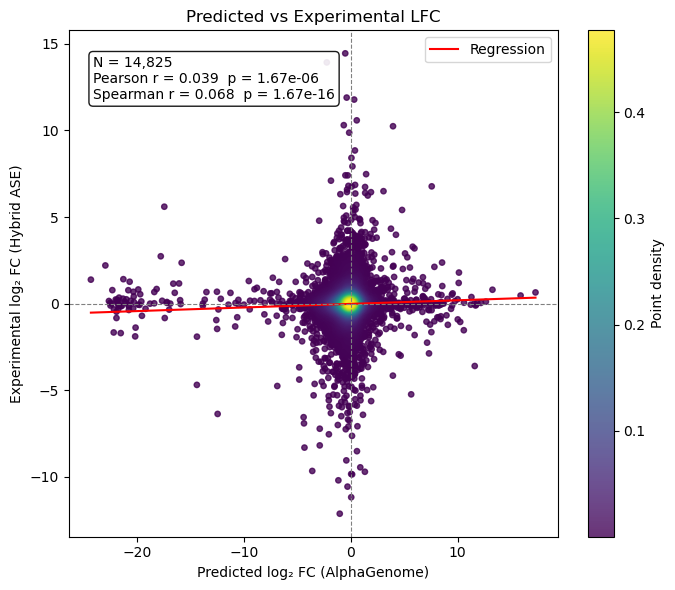

In [13]:
# --- 6a. Predicted LFC vs Experimental LFC ---
pred_lfc = joined['LFC'].to_numpy()
exp_lfc  = joined['ExpLBM_LFC_human_ref'].to_numpy()

mask = np.isfinite(pred_lfc) & np.isfinite(exp_lfc)
x, y = pred_lfc[mask], exp_lfc[mask]

xy = np.vstack([x, y])
z  = gaussian_kde(xy)(xy)
idx = z.argsort()

r_p, p_p = pearsonr(x, y)
r_s, p_s = spearmanr(x, y)
m, b = np.polyfit(x, y, 1)

fig, ax = plt.subplots(figsize=FIGSIZE_SQ)
sc = ax.scatter(x[idx], y[idx], c=z[idx], cmap='viridis', s=15, alpha=0.8)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, m*x_line + b, color='red', linewidth=1.5, label='Regression')
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Predicted log\u2082 FC (AlphaGenome)')
ax.set_ylabel('Experimental log\u2082 FC (Hybrid ASE)')
ax.set_title('Predicted vs Experimental LFC')
plt.colorbar(sc, ax=ax, label='Point density')
stats_text = f'N = {len(x):,}\nPearson r = {r_p:.3f}  p = {p_p:.2e}\nSpearman r = {r_s:.3f}  p = {p_s:.2e}'
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
ax.legend()
plt.tight_layout()
plt.show()

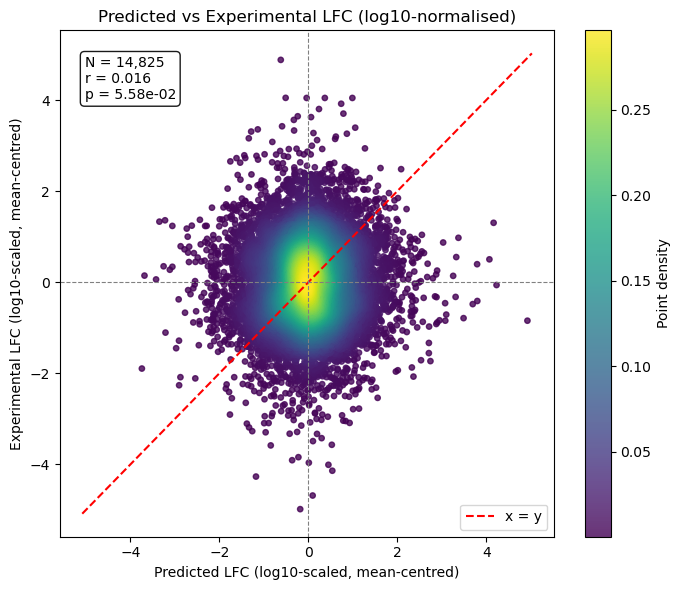

In [14]:
# --- 6b. log10-normalised scatter ---
log_pred = np.log10(np.abs(pred_lfc) + 1e-6) * np.sign(pred_lfc)
log_exp  = np.log10(np.abs(exp_lfc)  + 1e-6) * np.sign(exp_lfc)

mask = np.isfinite(log_pred) & np.isfinite(log_exp)
xn = log_pred[mask] - np.mean(log_pred[mask])
yn = log_exp[mask]  - np.mean(log_exp[mask])

xy = np.vstack([xn, yn])
z  = gaussian_kde(xy)(xy)
idx = z.argsort()

r_norm, p_norm = pearsonr(xn, yn)

fig, ax = plt.subplots(figsize=FIGSIZE_SQ)
sc = ax.scatter(xn[idx], yn[idx], c=z[idx], cmap='viridis', s=15, alpha=0.8)
lims = [min(xn.min(), yn.min())-0.1, max(xn.max(), yn.max())+0.1]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='x = y')
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Predicted LFC (log10-scaled, mean-centred)')
ax.set_ylabel('Experimental LFC (log10-scaled, mean-centred)')
ax.set_title('Predicted vs Experimental LFC (log10-normalised)')
plt.colorbar(sc, ax=ax, label='Point density')
ax.text(0.05, 0.95, f'N = {len(xn):,}\nr = {r_norm:.3f}\np = {p_norm:.2e}',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
ax.legend()
plt.tight_layout()
plt.show()

Direction agreement : 7,801 / 14,825  (52.6%)
Pearson r (direction) = 0.051  p = 3.81e-10


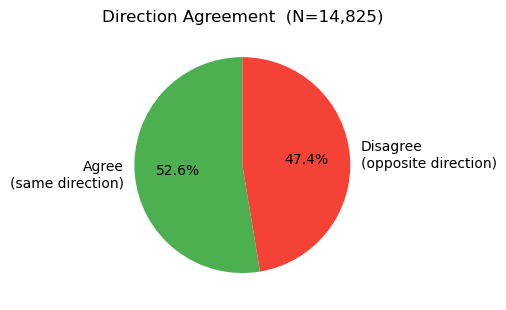

In [15]:
# --- 6c. Direction accuracy ---
direction_df = joined.with_columns(
    pl.col('LFC').sign().alias('pred_direction'),
    pl.col('ExpLBM_LFC_human_ref').sign().alias('exp_direction'),
).drop_nulls(subset=['pred_direction', 'exp_direction']).filter(
    (pl.col('pred_direction') != 0) & (pl.col('exp_direction') != 0)
)

n_agree     = direction_df.filter(pl.col('pred_direction') == pl.col('exp_direction')).height
n_disagree  = direction_df.filter(pl.col('pred_direction') != pl.col('exp_direction')).height
n_dir_total = direction_df.height

r_dir, p_dir = pearsonr(
    direction_df['pred_direction'].to_numpy(),
    direction_df['exp_direction'].to_numpy()
)

print(f'Direction agreement : {n_agree:,} / {n_dir_total:,}  ({100*n_agree/n_dir_total:.1f}%)')
print(f'Pearson r (direction) = {r_dir:.3f}  p = {p_dir:.2e}')

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie([n_agree, n_disagree],
       labels=['Agree\n(same direction)', 'Disagree\n(opposite direction)'],
       colors=['#4CAF50', '#F44336'],
       autopct='%1.1f%%', startangle=90)
ax.set_title(f'Direction Agreement  (N={n_dir_total:,})')
plt.tight_layout()
plt.show()

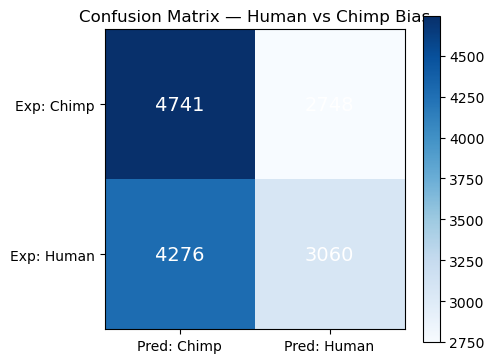

              precision    recall  f1-score   support

Chimp-biased       0.53      0.63      0.57      7489
Human-biased       0.53      0.42      0.47      7336

    accuracy                           0.53     14825
   macro avg       0.53      0.53      0.52     14825
weighted avg       0.53      0.53      0.52     14825



In [16]:
# --- 6d. Confusion matrix: human-biased / chimp-biased classification ---
from sklearn.metrics import confusion_matrix, classification_report

pred_cls = (direction_df['pred_direction'].to_numpy() > 0).astype(int)  # 1=human, 0=chimp
exp_cls  = (direction_df['exp_direction'].to_numpy()  > 0).astype(int)

cm = confusion_matrix(exp_cls, pred_cls)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred: Chimp', 'Pred: Human'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Exp: Chimp', 'Exp: Human'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)
ax.set_title('Confusion Matrix — Human vs Chimp Bias')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print(classification_report(exp_cls, pred_cls, target_names=['Chimp-biased', 'Human-biased']))

### 6e. Predicted vs Experimental LFC — ASE genes only

Repeat the LFC comparison restricted to genes classified as ASE (`ExpLBM_gene_ase_type == 'ASE'`) in the hybrid data.

All matched genes  : 16,651
ASE genes only     : 7,569  (45.5%)


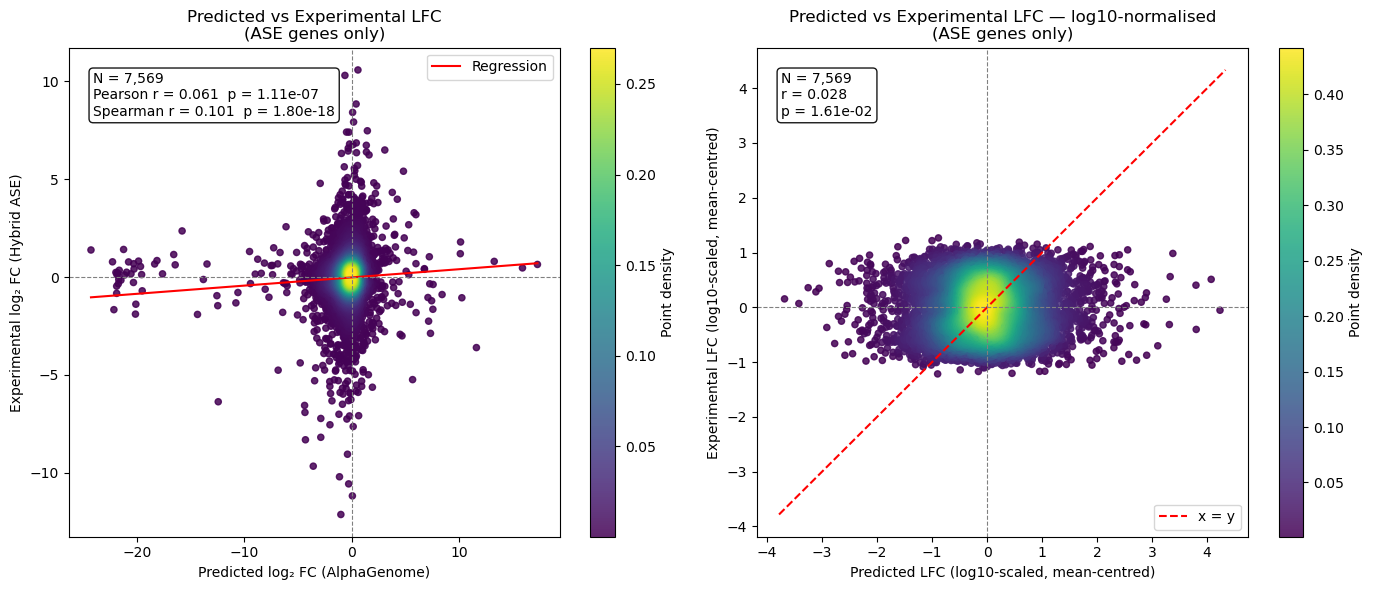


Direction agreement (ASE genes): 4,092 / 7,569  (54.1%)
Pearson r (direction, ASE)     : 0.082  p = 9.25e-13

Comparison — all genes vs ASE genes only:
  Pearson r  (LFC) : all = 0.039   ASE only = 0.061
  Spearman r (LFC) : all = 0.068   ASE only = 0.101
  Direction acc.   : all = 52.6%   ASE only = 54.1%


In [22]:
# --- 6e. Filter to ASE genes only ---
joined_ase = joined.filter(pl.col('ExpLBM_gene_ase_type') == 'ASE')
print(f'All matched genes  : {joined.height:,}')
print(f'ASE genes only     : {joined_ase.height:,}  ({100*joined_ase.height/joined.height:.1f}%)')

pred_lfc_ase = joined_ase['LFC'].to_numpy()
exp_lfc_ase  = joined_ase['ExpLBM_LFC_human_ref'].to_numpy()
mask_ase = np.isfinite(pred_lfc_ase) & np.isfinite(exp_lfc_ase)
x_ase, y_ase = pred_lfc_ase[mask_ase], exp_lfc_ase[mask_ase]

# Raw scatter
xy_ase = np.vstack([x_ase, y_ase])
z_ase  = gaussian_kde(xy_ase)(xy_ase)
idx_ase = z_ase.argsort()

r_p_ase, p_p_ase = pearsonr(x_ase, y_ase)
r_s_ase, p_s_ase = spearmanr(x_ase, y_ase)
m_ase, b_ase = np.polyfit(x_ase, y_ase, 1)

# log10-normalised
log_pred_ase = np.log10(np.abs(x_ase) + 1e-6) * np.sign(x_ase)
log_exp_ase  = np.log10(np.abs(y_ase) + 1e-6) * np.sign(y_ase)
mask_n = np.isfinite(log_pred_ase) & np.isfinite(log_exp_ase)
xn_ase = log_pred_ase[mask_n] - np.mean(log_pred_ase[mask_n])
yn_ase = log_exp_ase[mask_n]  - np.mean(log_exp_ase[mask_n])
xy_n = np.vstack([xn_ase, yn_ase])
z_n  = gaussian_kde(xy_n)(xy_n)
idx_n = z_n.argsort()
r_norm_ase, p_norm_ase = pearsonr(xn_ase, yn_ase)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
sc = ax.scatter(x_ase[idx_ase], y_ase[idx_ase], c=z_ase[idx_ase], cmap='viridis', s=20, alpha=0.85)
x_line = np.linspace(x_ase.min(), x_ase.max(), 200)
ax.plot(x_line, m_ase * x_line + b_ase, color='red', linewidth=1.5, label='Regression')
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Predicted log₂ FC (AlphaGenome)')
ax.set_ylabel('Experimental log₂ FC (Hybrid ASE)')
ax.set_title('Predicted vs Experimental LFC\n(ASE genes only)')
plt.colorbar(sc, ax=ax, label='Point density')
stats_text = (f'N = {len(x_ase):,}\n'
              f'Pearson r = {r_p_ase:.3f}  p = {p_p_ase:.2e}\n'
              f'Spearman r = {r_s_ase:.3f}  p = {p_s_ase:.2e}')
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
ax.legend()

ax = axes[1]
sc2 = ax.scatter(xn_ase[idx_n], yn_ase[idx_n], c=z_n[idx_n], cmap='viridis', s=20, alpha=0.85)
lims = [min(xn_ase.min(), yn_ase.min()) - 0.1, max(xn_ase.max(), yn_ase.max()) + 0.1]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='x = y')
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Predicted LFC (log10-scaled, mean-centred)')
ax.set_ylabel('Experimental LFC (log10-scaled, mean-centred)')
ax.set_title('Predicted vs Experimental LFC — log10-normalised\n(ASE genes only)')
plt.colorbar(sc2, ax=ax, label='Point density')
ax.text(0.05, 0.95, f'N = {len(xn_ase):,}\nr = {r_norm_ase:.3f}\np = {p_norm_ase:.2e}',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
ax.legend()

plt.tight_layout()
plt.show()

# Direction accuracy (ASE genes)
dir_ase = joined_ase.with_columns(
    pl.col('LFC').sign().alias('pred_direction'),
    pl.col('ExpLBM_LFC_human_ref').sign().alias('exp_direction'),
).drop_nulls(subset=['pred_direction', 'exp_direction']).filter(
    (pl.col('pred_direction') != 0) & (pl.col('exp_direction') != 0)
)
n_agree_ase    = dir_ase.filter(pl.col('pred_direction') == pl.col('exp_direction')).height
n_disagree_ase = dir_ase.filter(pl.col('pred_direction') != pl.col('exp_direction')).height
n_dir_ase      = dir_ase.height
r_dir_ase, p_dir_ase = pearsonr(
    dir_ase['pred_direction'].to_numpy(),
    dir_ase['exp_direction'].to_numpy()
)

print(f'\nDirection agreement (ASE genes): {n_agree_ase:,} / {n_dir_ase:,}  ({100*n_agree_ase/n_dir_ase:.1f}%)')
print(f'Pearson r (direction, ASE)     : {r_dir_ase:.3f}  p = {p_dir_ase:.2e}')
print(f'\nComparison — all genes vs ASE genes only:')
print(f'  Pearson r  (LFC) : all = {r_p:.3f}   ASE only = {r_p_ase:.3f}')
print(f'  Spearman r (LFC) : all = {r_s:.3f}   ASE only = {r_s_ase:.3f}')
print(f'  Direction acc.   : all = {100*n_agree/n_dir_total:.1f}%   ASE only = {100*n_agree_ase/n_dir_ase:.1f}%')

## 7. Predicted vs Experimental Per-Species Expression

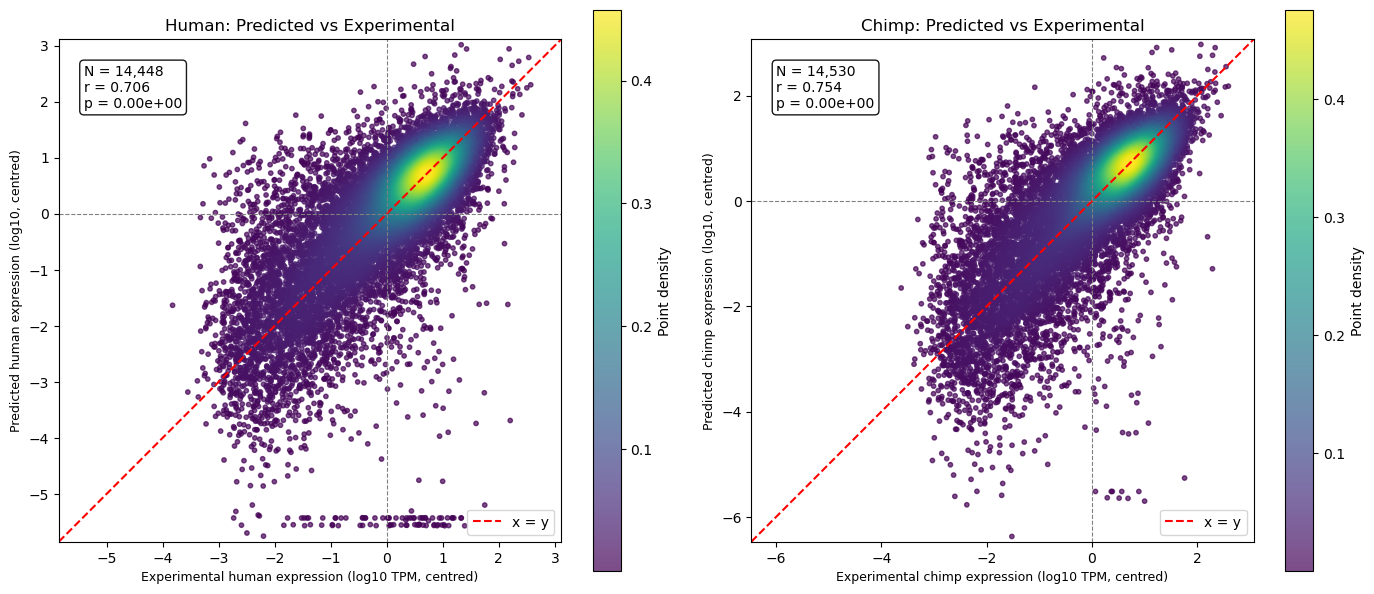

In [17]:
def scatter_pred_vs_exp(ax, exp_raw, pred_raw, xlabel, ylabel, title):
    x_raw = np.log10(np.array(exp_raw,  dtype=float))
    y_raw = np.log10(np.array(pred_raw, dtype=float))
    mask = np.isfinite(x_raw) & np.isfinite(y_raw)
    x = x_raw[mask] - np.mean(x_raw[mask])
    y = y_raw[mask] - np.mean(y_raw[mask])
    xy = np.vstack([x, y])
    z  = gaussian_kde(xy)(xy)
    idx = z.argsort()
    r, p = pearsonr(x, y)
    sc = ax.scatter(x[idx], y[idx], c=z[idx], cmap='viridis', s=10, alpha=0.7)
    lims = [min(x.min(), y.min())-0.1, max(x.max(), y.max())+0.1]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='x = y')
    ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect('equal', adjustable='box')
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title)
    ax.text(0.05, 0.95, f'N = {len(x):,}\nr = {r:.3f}\np = {p:.2e}',
            transform=ax.transAxes, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    return sc

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = scatter_pred_vs_exp(
    axes[0],
    joined['ExpLBM_TPM_human_allele'].to_numpy(),
    joined['HumanGeneExpression'].to_numpy(),
    'Experimental human expression (log10 TPM, centred)',
    'Predicted human expression (log10, centred)',
    'Human: Predicted vs Experimental'
)
sc2 = scatter_pred_vs_exp(
    axes[1],
    joined['ExpLBM_TPM_chimp_allele'].to_numpy(),
    joined['ChimpGeneExpression'].to_numpy(),
    'Experimental chimp expression (log10 TPM, centred)',
    'Predicted chimp expression (log10, centred)',
    'Chimp: Predicted vs Experimental'
)

for ax, sc in [(axes[0], sc1), (axes[1], sc2)]:
    plt.colorbar(sc, ax=ax, label='Point density')
    ax.legend()

plt.tight_layout()
plt.show()

## 8. Lineage-Causing Change Analysis

In [18]:
lineage = pl.read_csv(config.LINEAGE_CAUSING_CHANGE_DATA, separator='\t')
print(f'Lineage data rows : {lineage.height:,}')
print(f'Columns           : {lineage.columns}')
lineage.head(3)

Lineage data rows : 92,619
Columns           : ['Gene', 'ExpLBM_TPM_human_allele', 'ExpLBM_TPM_human_allele_HG', 'ExpLBM_TPM_chimp_allele', 'ExpLBM_TPM_gorilla_allele', 'ExpLBM_TPM_total', 'ExpLBM_log2TPM_human_allele', 'ExpLBM_log2TPM_human_allele_HG', 'ExpLBM_log2TPM_chimp_allele', 'ExpLBM_log2TPM_gorilla_allele', 'ExpLBM_log2TPM_total', 'ExpLBM_LFC_human_ref', 'ExpLBM_LFC_padj_human_ref', 'ExpLBM_LFC_chimp_ref', 'ExpLBM_LFC_padj_chimp_ref', 'ExpLBM_gene_ase_type', 'd_GH', 'd_GC', 'G_clipped', 'human_derived_score', 'derived']


Gene,ExpLBM_TPM_human_allele,ExpLBM_TPM_human_allele_HG,ExpLBM_TPM_chimp_allele,ExpLBM_TPM_gorilla_allele,ExpLBM_TPM_total,ExpLBM_log2TPM_human_allele,ExpLBM_log2TPM_human_allele_HG,ExpLBM_log2TPM_chimp_allele,ExpLBM_log2TPM_gorilla_allele,ExpLBM_log2TPM_total,ExpLBM_LFC_human_ref,ExpLBM_LFC_padj_human_ref,ExpLBM_LFC_chimp_ref,ExpLBM_LFC_padj_chimp_ref,ExpLBM_gene_ase_type,d_GH,d_GC,G_clipped,human_derived_score,derived
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,str
"""A1BG""",0.589528,0.851414,0.527905,1.412338,2.210705,0.668598,0.888627,0.611555,1.270432,1.68289,0.230332,0.394157,0.268019,0.307232,"""nonASE""",0.601834,0.658877,0.589528,-1.0,"""chimp-derived"""
"""A2M""",1.409486,1.597975,1.120505,1.318553,4.860193,1.268725,1.377387,1.084408,1.213224,2.550948,0.351554,0.011117,0.278937,0.053456,"""nonASE""",0.055501,0.128817,1.318553,-0.370662,"""chimp-derived"""
"""A2MP1""",0.011313,0.030674,0.016085,0.006907,0.036106,0.01623,0.043588,0.023021,0.009931,0.051171,-0.124703,0.848341,0.20574,0.684719,"""else""",0.006299,0.01309,0.011313,-1.0,"""chimp-derived"""


In [19]:
# Join predictions with lineage data — adjust key column name if needed
gene_col_lineage = [c for c in lineage.columns if 'gene' in c.lower() or 'symbol' in c.lower()]
print(f'Candidate gene columns in lineage data: {gene_col_lineage}')

if gene_col_lineage:
    key = gene_col_lineage[0]
    lineage_joined = df_clean.join(lineage, left_on='GeneSymbol', right_on=key, how='inner')
    print(f'Matched genes: {lineage_joined.height:,}')
    lineage_joined.head(3)
else:
    print('Could not auto-detect gene column — adjust join key manually.')

Candidate gene columns in lineage data: ['Gene', 'ExpLBM_gene_ase_type']
Matched genes: 16,651


In [20]:
# Plot predicted LFC stratified by lineage-causing change category
cat_cols = [c for c in lineage_joined.columns if 'lineage' in c.lower() or 'category' in c.lower() or 'polariz' in c.lower()]
print(f'Candidate category columns: {cat_cols}')

if cat_cols:
    cat_col = cat_cols[0]
    categories = lineage_joined[cat_col].unique().to_list()
    print(f'Using: {cat_col}  |  categories: {categories}')

    fig, ax = plt.subplots(figsize=(8, 5))
    data_by_cat = [
        lineage_joined.filter(pl.col(cat_col) == c)['LFC'].drop_nulls().to_numpy()
        for c in categories
    ]
    ax.boxplot(data_by_cat, labels=categories, patch_artist=True)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Lineage category')
    ax.set_ylabel('Predicted log\u2082 FC (Human / Chimp)')
    ax.set_title('Predicted LFC by Lineage-Causing Change Category')
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No category column found — inspect lineage_joined.columns and adjust.')

Candidate category columns: []
No category column found — inspect lineage_joined.columns and adjust.


## 9. Summary

In [21]:
print('=' * 55)
print('  AlphaGenome Predictions — Summary')
print('=' * 55)
print(f'  Total gene pairs loaded        : {total:,}')
print(f'  Complete (both expr computed)  : {complete:,}  ({100*complete/total:.1f}%)')
print(f'  Missing LFC                    : {null_lfc:,}')
print()
print(f'  LFC stats (complete pairs)')
print(f'    Mean        : {mean_lfc:.3f}')
print(f'    Median      : {median_lfc:.3f}')
print(f'    SD          : {std_lfc:.3f}')
print(f'    Human-biased (LFC>0) : {n_human_biased:,}  ({100*n_human_biased/len(lfc):.1f}%)')
print(f'    Chimp-biased (LFC<0) : {n_chimp_biased:,}  ({100*n_chimp_biased/len(lfc):.1f}%)')
print()
try:
    print(f'  vs Hybrid ASE (N={len(x):,} matched genes)')
    print(f'    Pearson r (LFC)      : {r_p:.3f}  p = {p_p:.2e}')
    print(f'    Spearman r (LFC)     : {r_s:.3f}  p = {p_s:.2e}')
    print(f'    Direction accuracy   : {100*n_agree/n_dir_total:.1f}%')
except NameError:
    print('  (hybrid comparison not run — check Section 6)')
print('=' * 55)

  AlphaGenome Predictions — Summary
  Total gene pairs loaded        : 17,000
  Complete (both expr computed)  : 16,970  (99.8%)
  Missing LFC                    : 30

  LFC stats (complete pairs)
    Mean        : -0.336
    Median      : -0.149
    SD          : 1.997
    Human-biased (LFC>0) : 6,753  (39.8%)
    Chimp-biased (LFC<0) : 10,217  (60.2%)

  vs Hybrid ASE (N=14,825 matched genes)
    Pearson r (LFC)      : 0.039  p = 1.67e-06
    Spearman r (LFC)     : 0.068  p = 1.67e-16
    Direction accuracy   : 52.6%
